In [1]:

from matplotlib import pyplot as plt



def plotData(data1, data2, title1, title2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
    ax1.hist(data1, 20)
    ax1.set_title(title1)
    ax2.hist(data2, 20)
    ax2.set_title(title2)
    plt.show()

def logNormalize(data):
    return [log(x) for x in data if pd.notna(x) and x > 0]

def minMaxNormalize(data):
    min_val = min(x for x in data if pd.notna(x))
    max_val = max(x for x in data if pd.notna(x))
    if(max_val - min_val) == 0:
        return [0 for x in data if pd.notna(x)]
    return [(x - min_val) / (max_val - min_val) for x in data if pd.notna(x)]

def clippingNormalize(data,thresholdMin = None, thresholdMax = None):
    if thresholdMin is not None:
        data = [max(x, thresholdMin) for x in data if pd.notna(x)]
    if thresholdMax is not None:
        data = [min(x, thresholdMax) for x in data if pd.notna(x)]
    return data

def zNormalize(data):
    s = data.std()
    mean = data.mean()
    return [(x - mean) / s for x in data if pd.notna(x)]

C:\Users\Deny\AppData\Local\Temp\ipykernel_23788\4090372945.py:4: DtypeWarning: Columns (0: Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Domo, 1: Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Thoughtspot ) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("surveyDataSience.csv",header = 1)


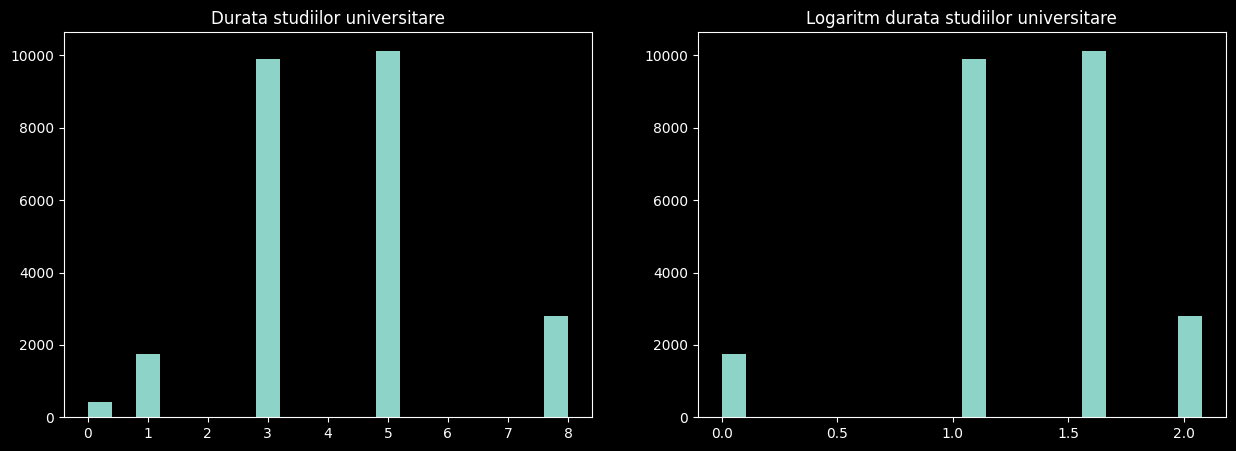

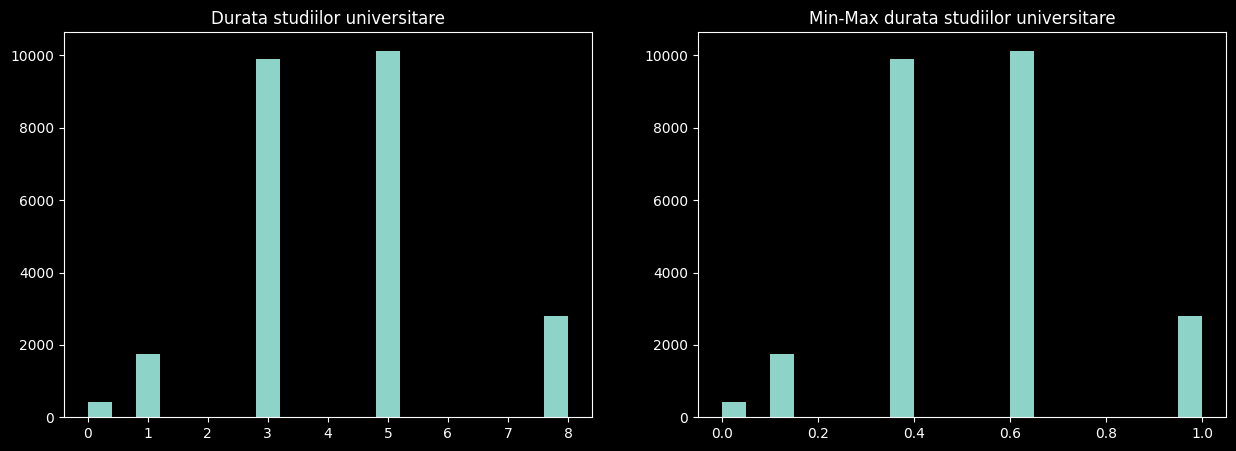

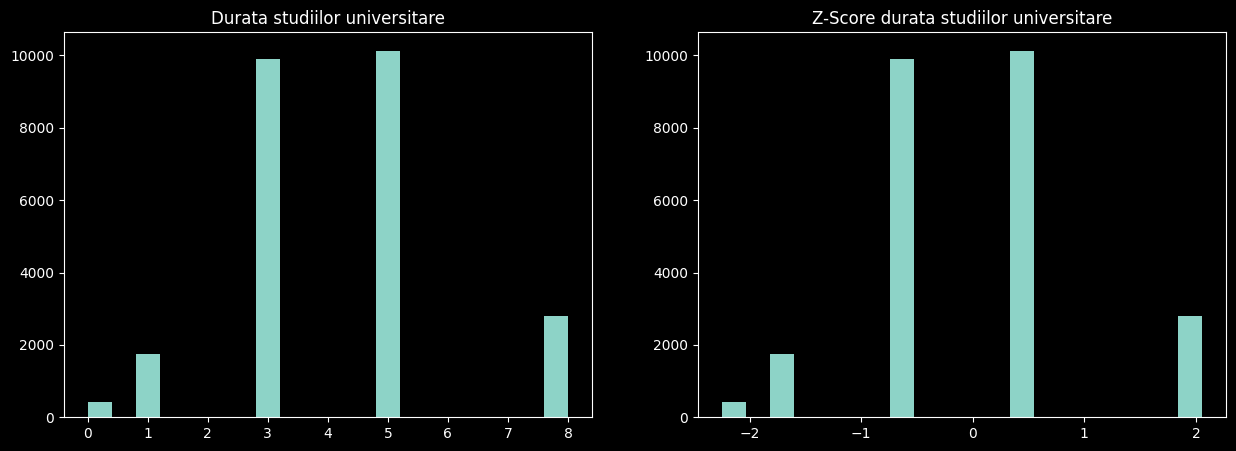

In [6]:
import pandas as pd
from math import log
import matplotlib.pyplot as plt
df = pd.read_csv("surveyDataSience.csv",header = 1)
education_col = "What is the highest level of formal education that you have attained or plan to attain within the next 2 years?"
education_map = {
    "No formal education past high school": 0,
    "Some college/university study without earning a bachelor’s degree": 1,
    "Bachelor’s degree": 3,
    "Master’s degree": 5,
    "Doctoral degree": 8

}

df["YearsEducation"] = df[education_col].map(education_map)
plotData(df["YearsEducation"], logNormalize(df["YearsEducation"]), "Durata studiilor universitare", "Logaritm durata studiilor universitare")
plotData(df["YearsEducation"], minMaxNormalize(df["YearsEducation"]), "Durata studiilor universitare", "Min-Max durata studiilor universitare")
plotData(df["YearsEducation"], zNormalize(df["YearsEducation"]), "Durata studiilor universitare", "Z-Score durata studiilor universitare")

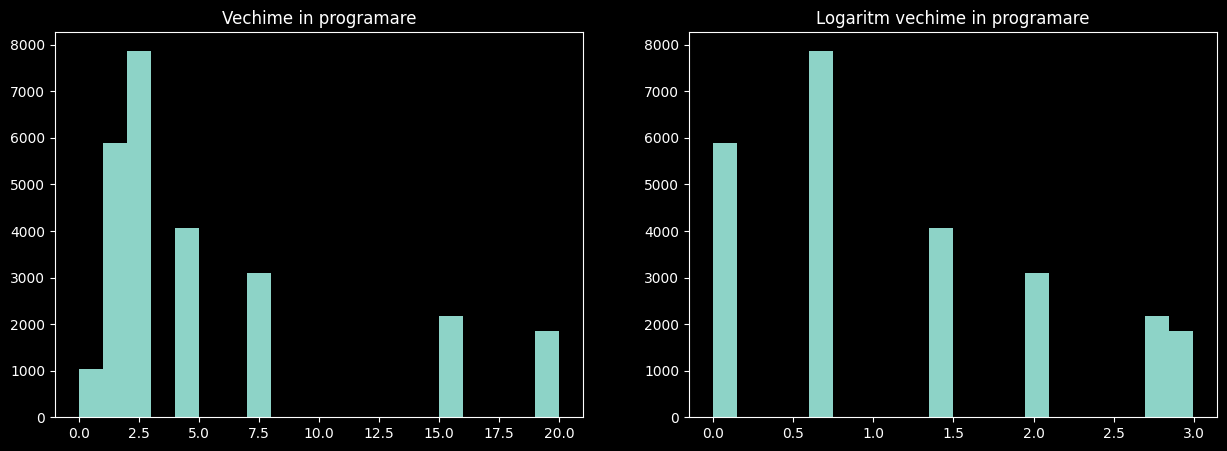

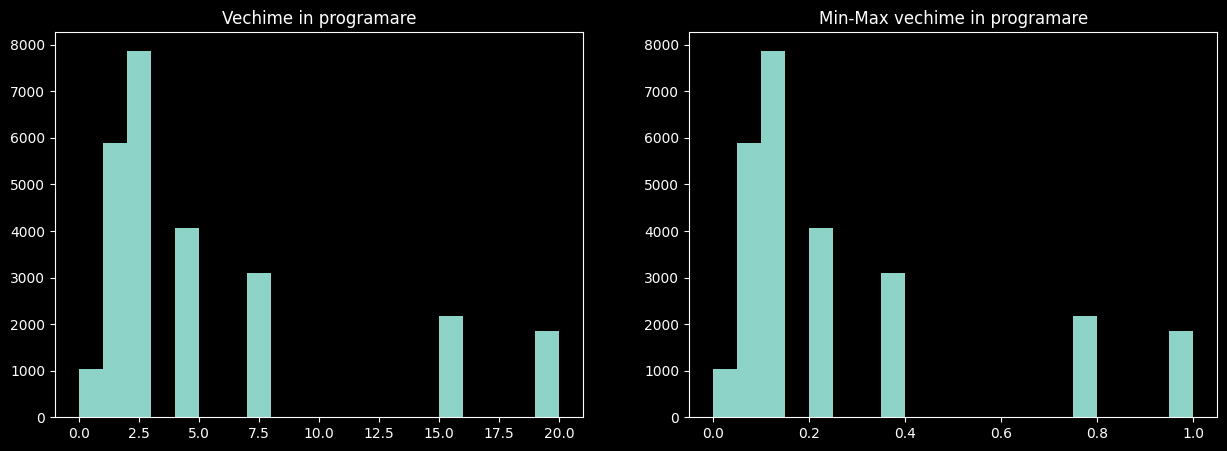

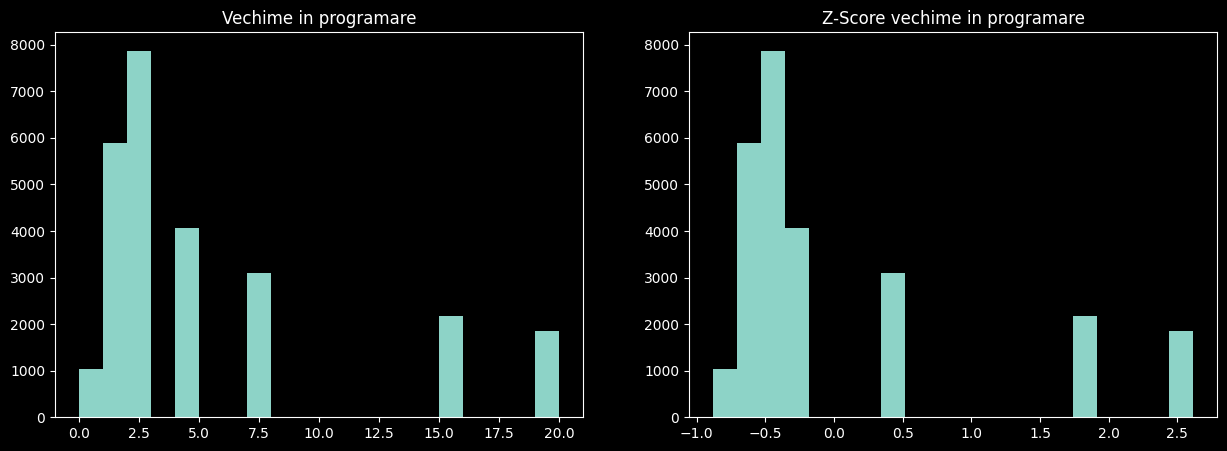

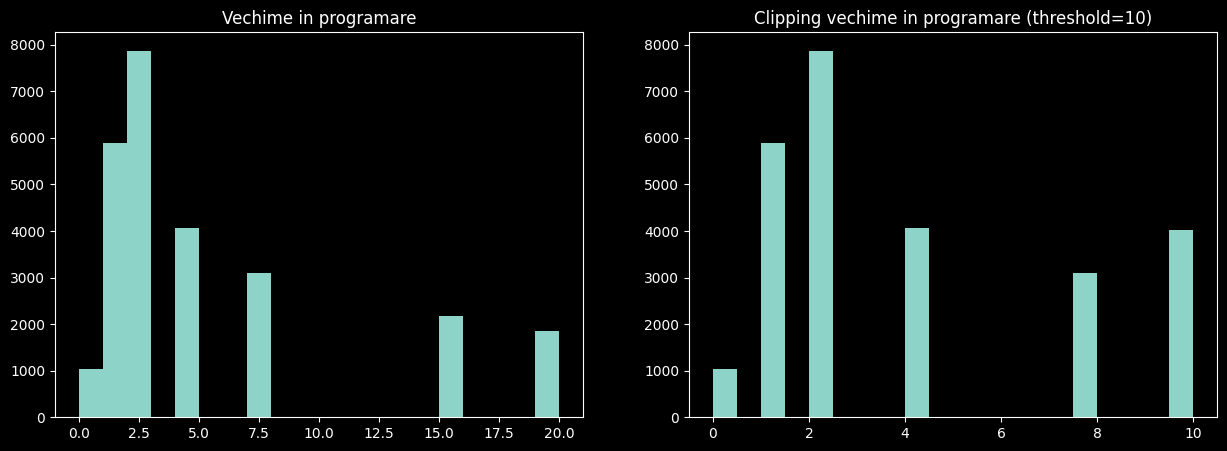

In [7]:
def mid_interval(interval):
    if pd.isna(interval):
        return np.nan
    interval = interval.replace("years","")
    if "+" in interval:
        return float(interval.replace("+", ""))
    if "<" in interval:
        return float(interval.replace("<",""))
    if "never" in interval:
        return 0.0
    parts = interval.split("-")
    return (float(parts[0]) + float(parts[1])) / 2

exp_col = "For how many years have you been writing code and/or programming?"

df["ExperienceYears"] = df[exp_col].apply(mid_interval)

plotData(df["ExperienceYears"], logNormalize(df["ExperienceYears"]), "Vechime in programare", "Logaritm vechime in programare")
plotData(df["ExperienceYears"], minMaxNormalize(df["ExperienceYears"]), "Vechime in programare", "Min-Max vechime in programare")
plotData(df["ExperienceYears"], zNormalize(df["ExperienceYears"]), "Vechime in programare", "Z-Score vechime in programare")
plotData(df["ExperienceYears"], clippingNormalize(df["ExperienceYears"], thresholdMax=10), "Vechime in programare", "Clipping vechime in programare (threshold=10)")

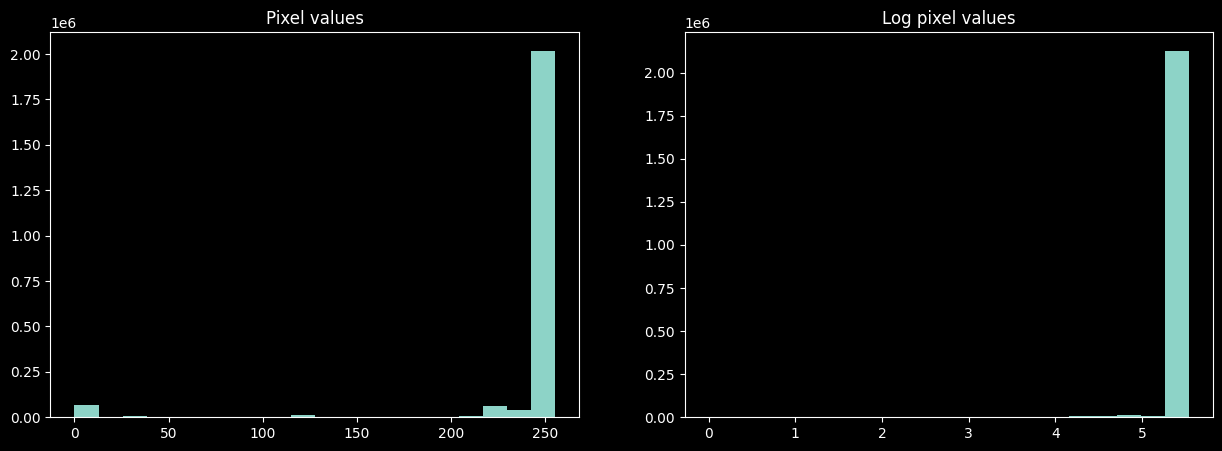

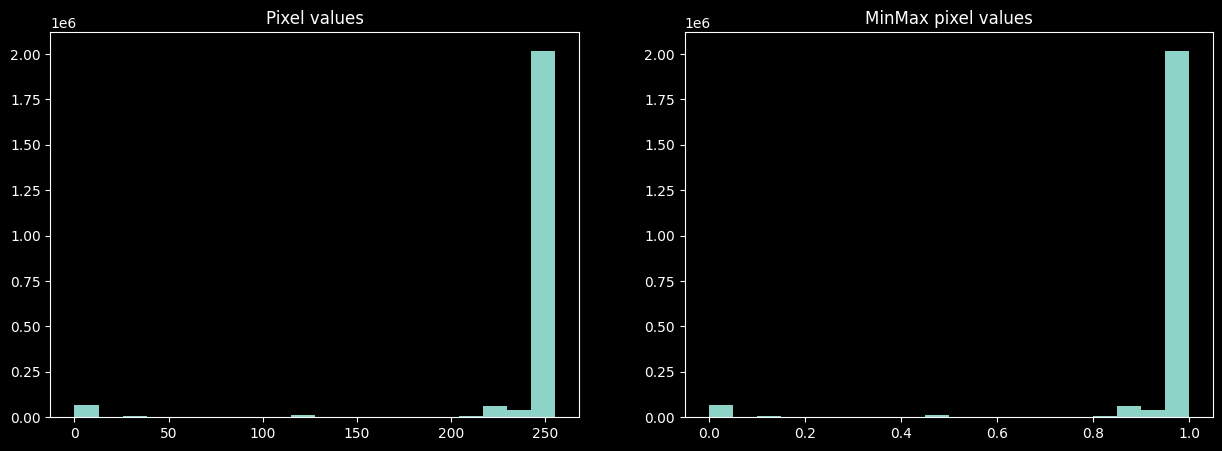

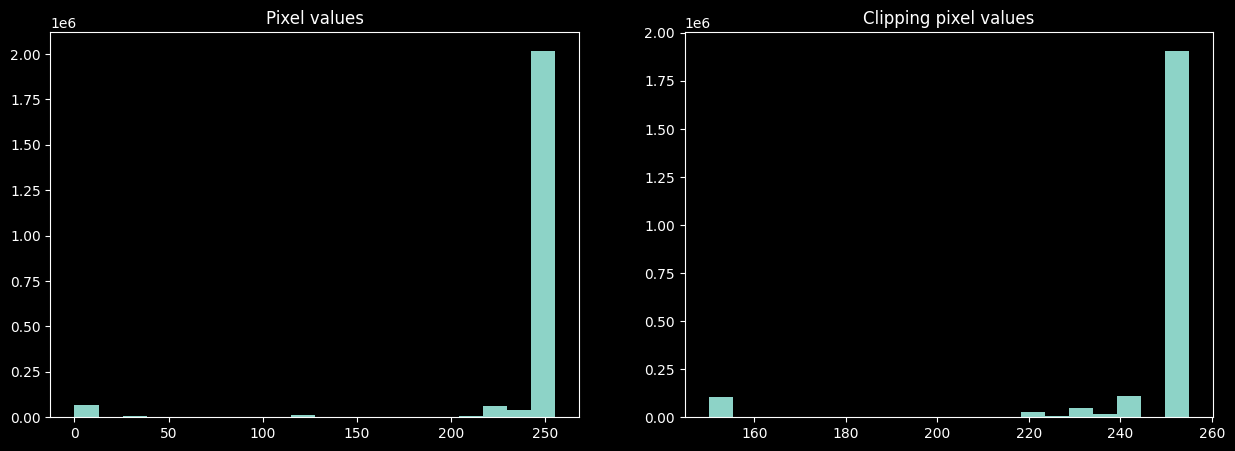

In [9]:
import numpy as np
from PIL import Image

img = Image.open("images/BERT.png").convert("L")   # grayscale
pixels = np.array(img)

all_pixels = pixels.flatten()
plotData(all_pixels,
         logNormalize(all_pixels),
         "Pixel values",
         "Log pixel values")

plotData(all_pixels,
         minMaxNormalize(all_pixels),
         "Pixel values",
         "MinMax pixel values")

plotData(all_pixels,
         clippingNormalize(all_pixels, 150),
         "Pixel values",
         "Clipping pixel values")

['Mesaj de informare:\nCursul și laboratoarele de Inteligență Artificială vor fi o\nprovocare pentru toți.', 'Suntem convinși că veți realiza proiecte\nfoarte interesante.', 'Vă încurajăm să adresați întrebări atunci\ncând ceva nu e clar, atât în mod live, cât și folosind platforma\nTeams, canalul ”general”.', 'Dacă ați citit până aici, vă rugăm să lăsați un mesaj pe canalul\ngeneral cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm că am citit\ntextul pentru problema 3 din lab2”.', '--\nMesaj de informare generat de ChatGPT:\nStimați cursanți,\nSuntem încântați să vă avem în echipa noastră pentru Cursul și\nlaboratoarele de Inteligență Artificială.', 'Această experiență va\nfi o adevărată provocare, dar suntem convinși că veți realiza\nproiecte extrem de interesante.', 'Vă încurajăm să fiți activi și să adresați întrebări atunci când\nceva nu este clar.', 'Fie că este vorba de o discuție în timp real\nsau prin intermediul platformei Teams, canalul ”general”, suntem\naici să vă sprijinim.'

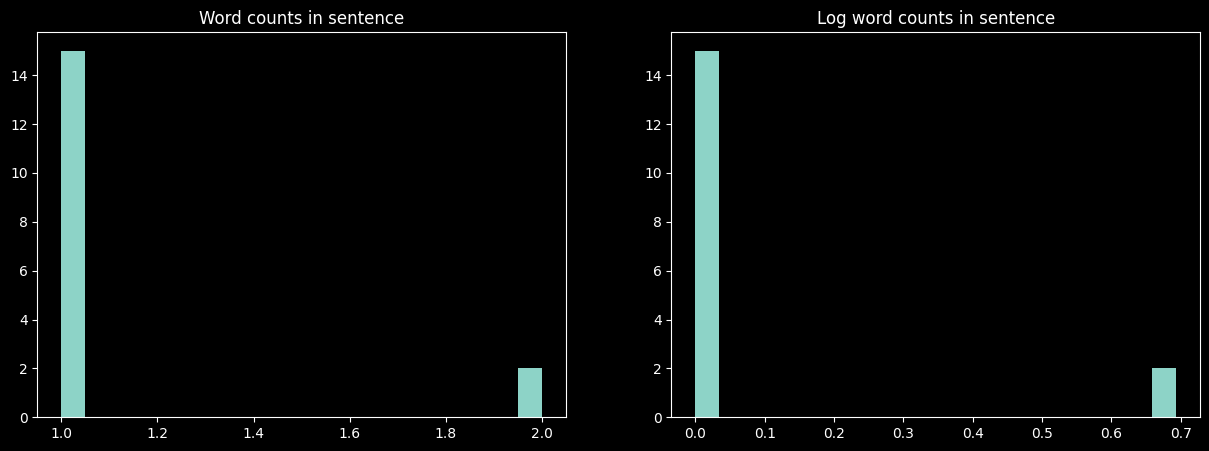

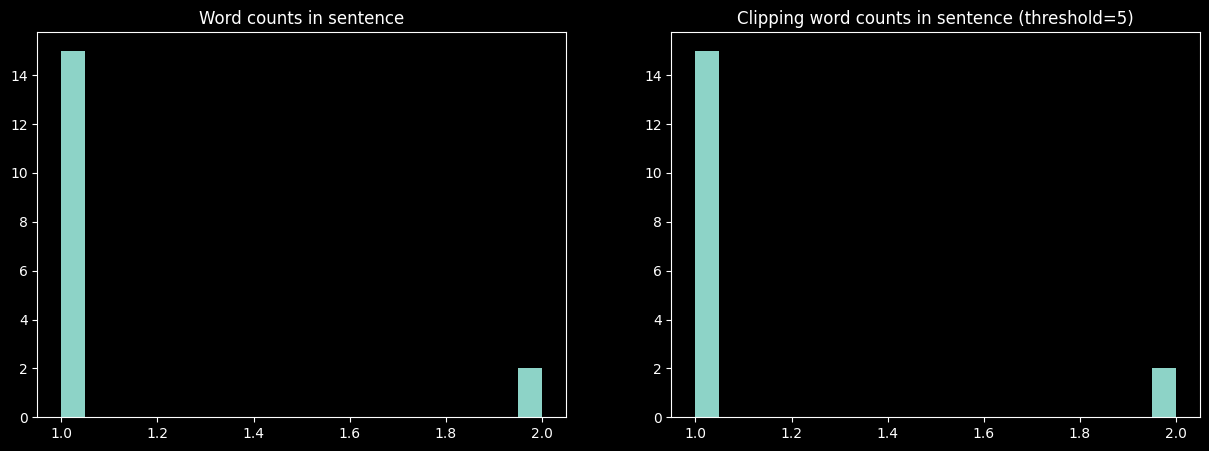

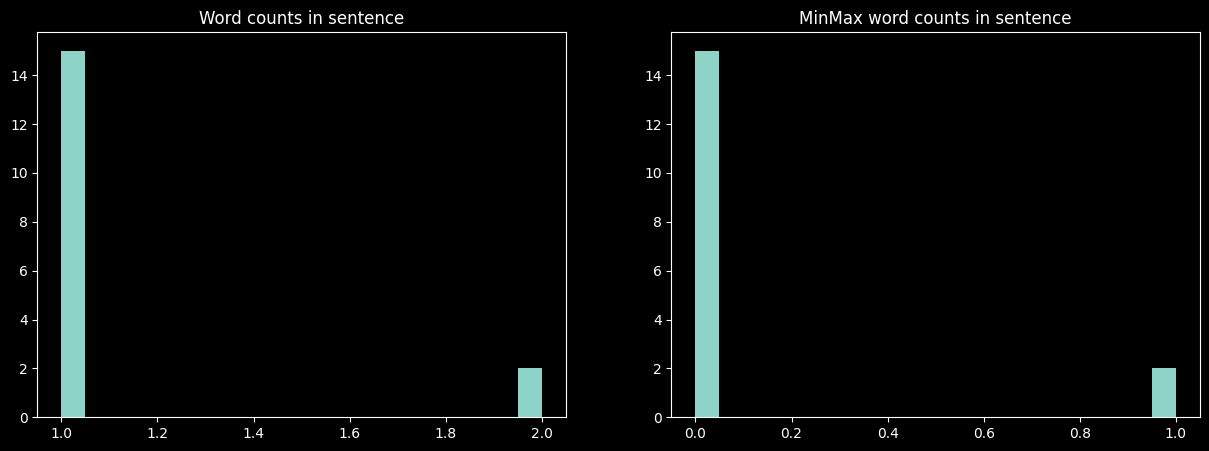

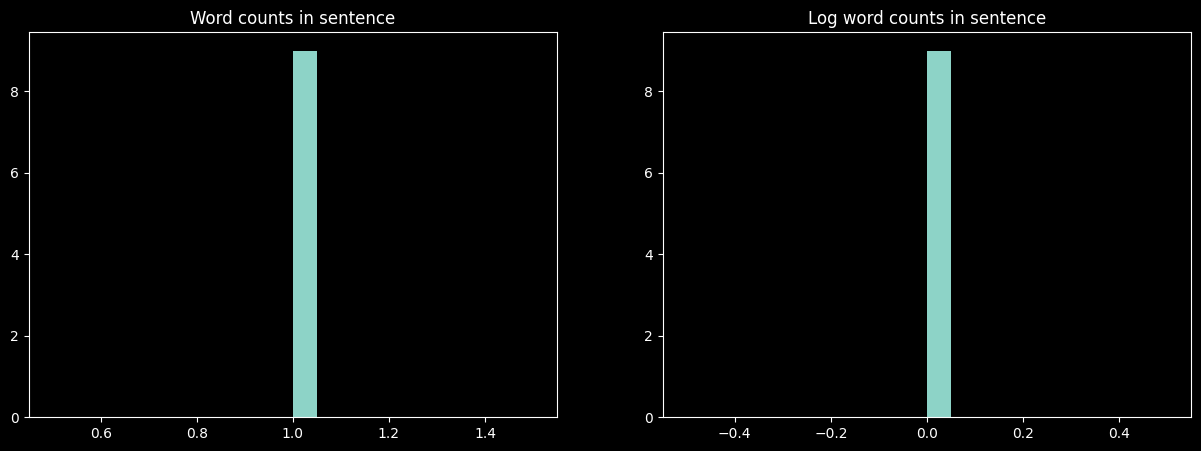

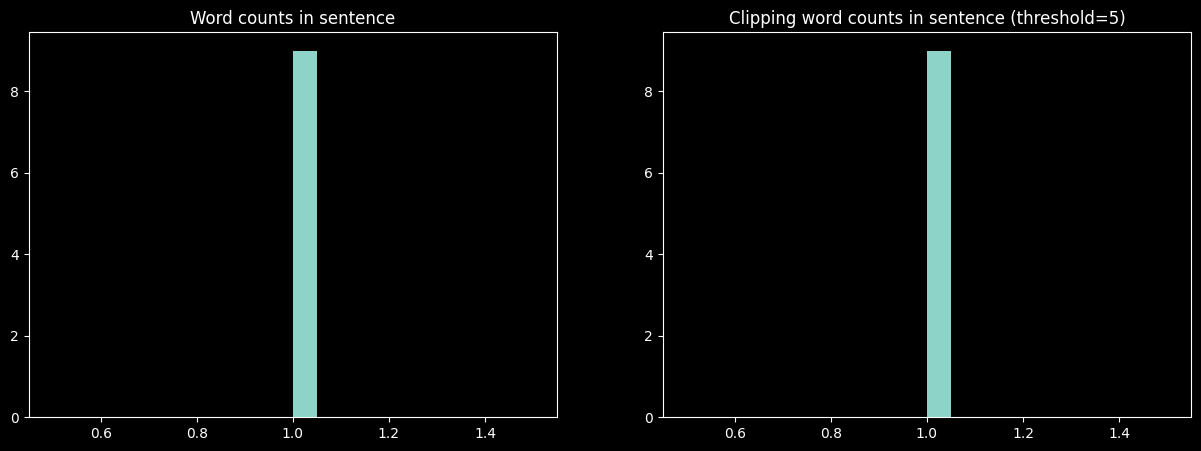

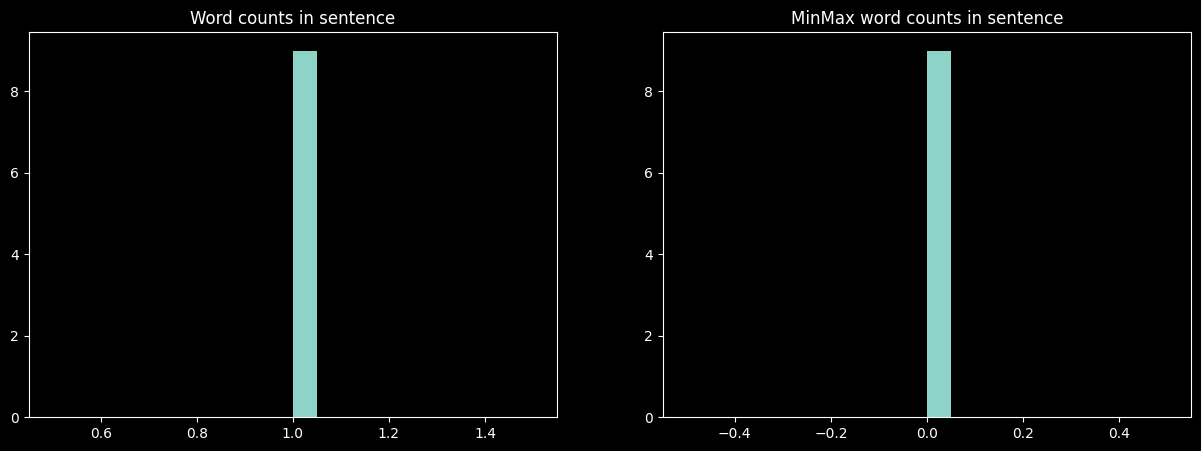

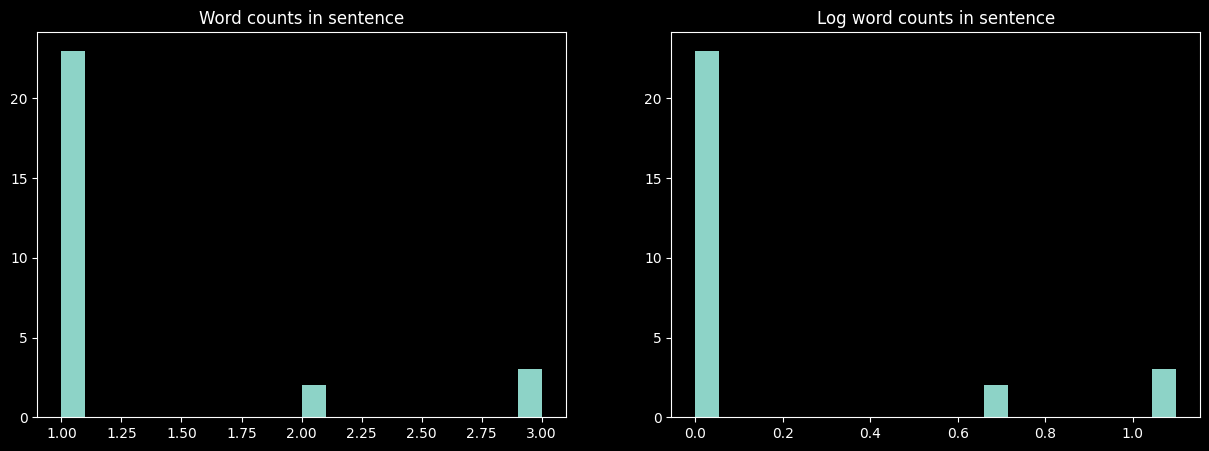

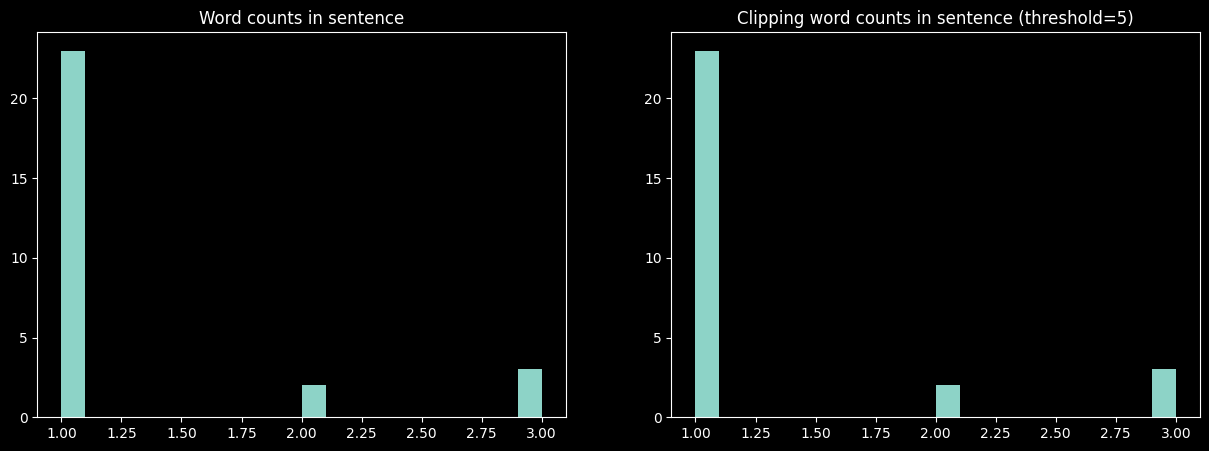

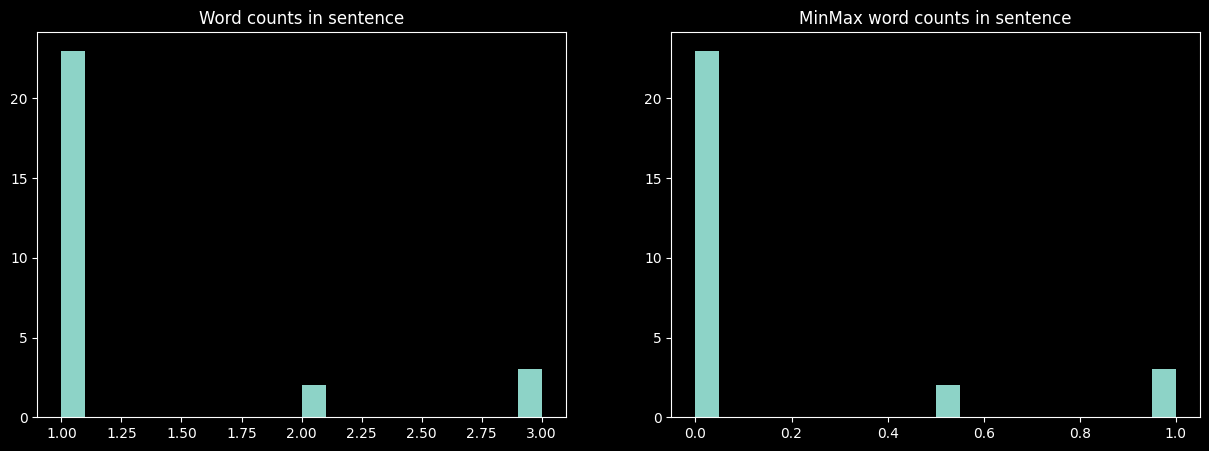

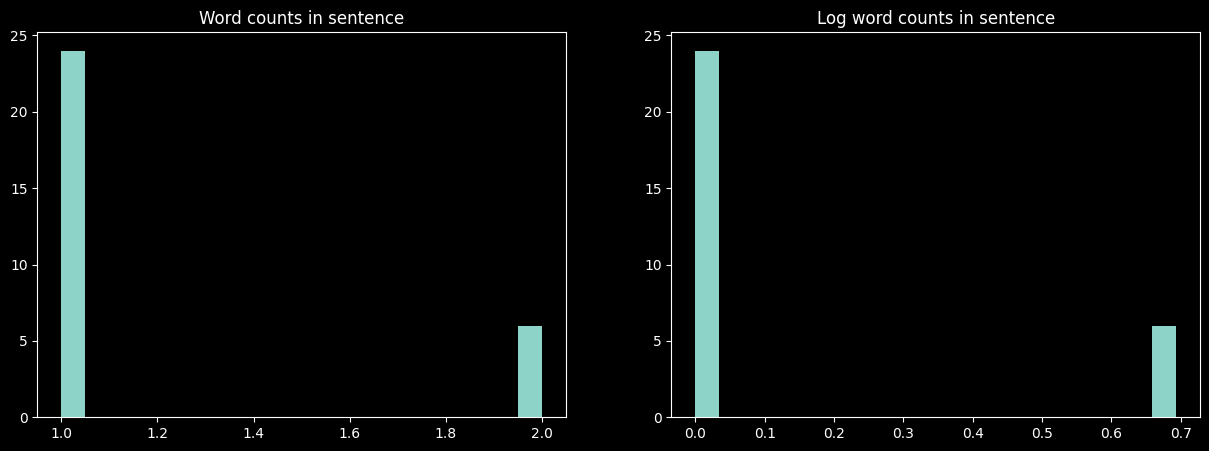

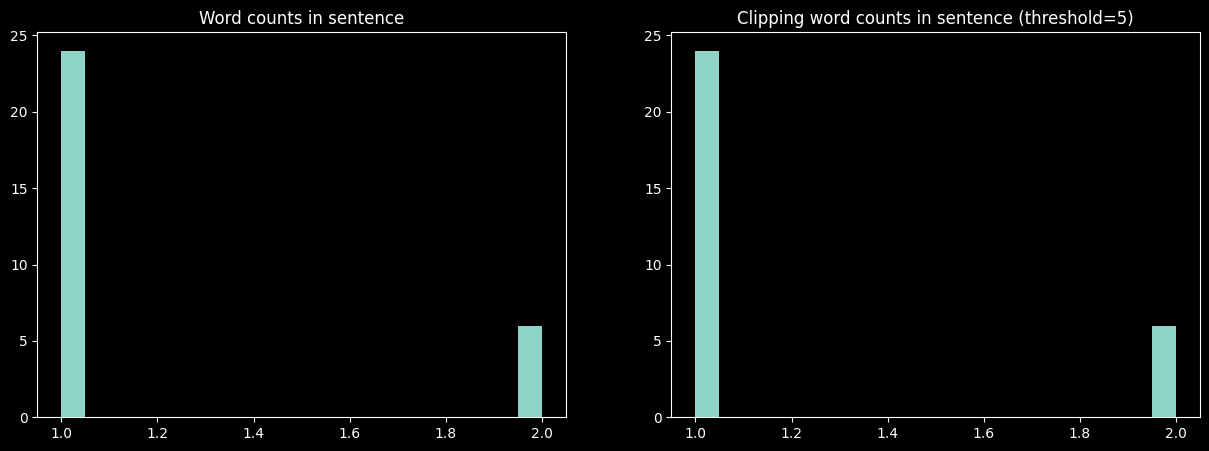

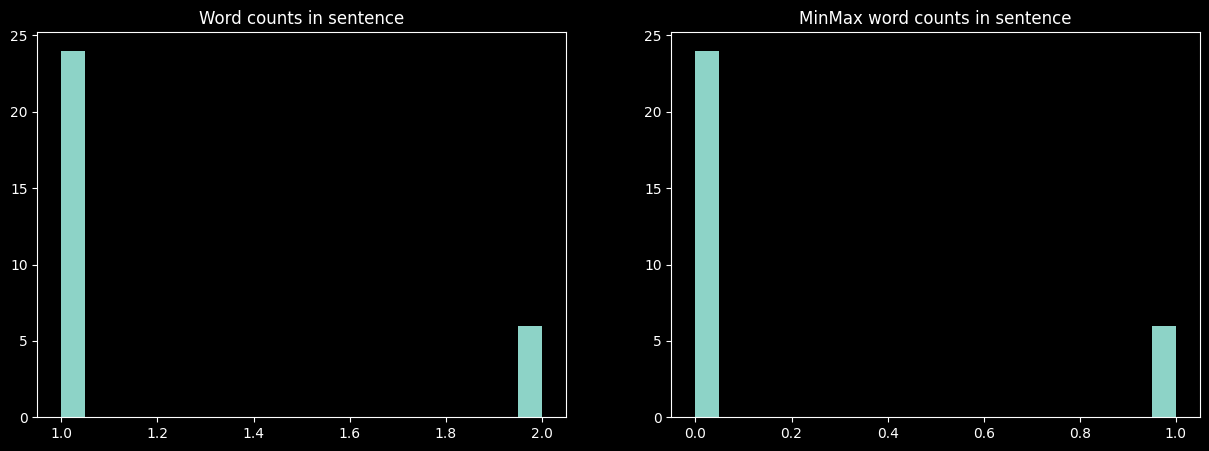

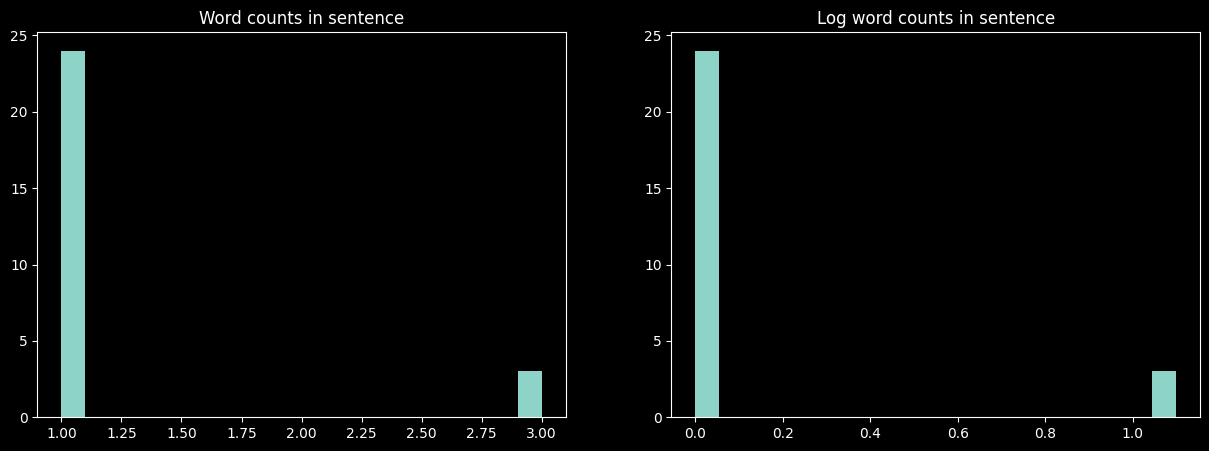

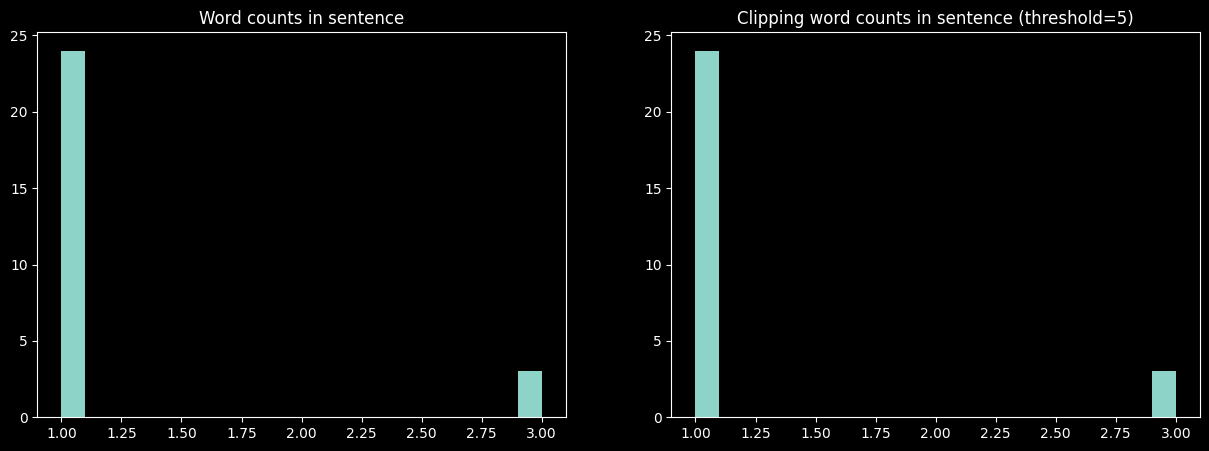

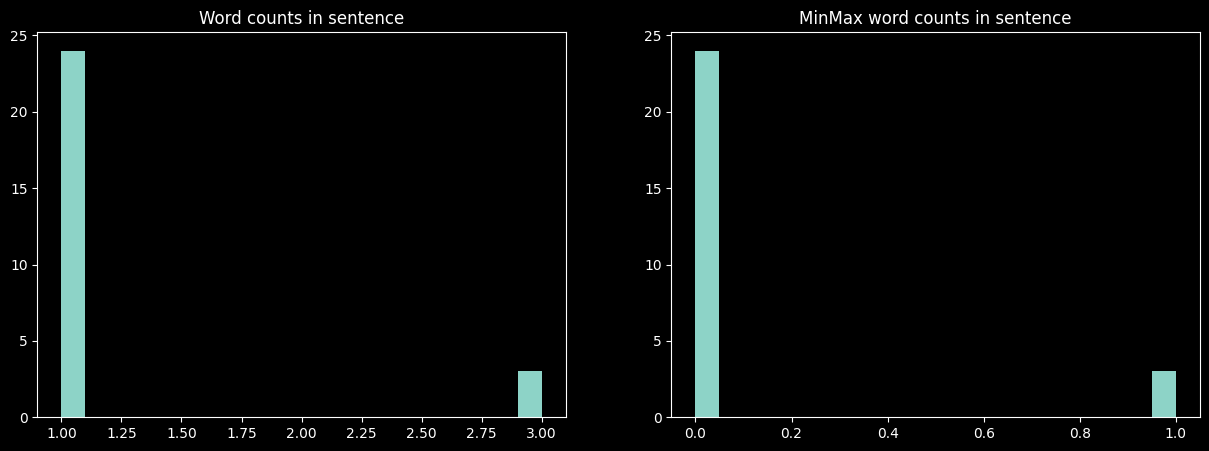

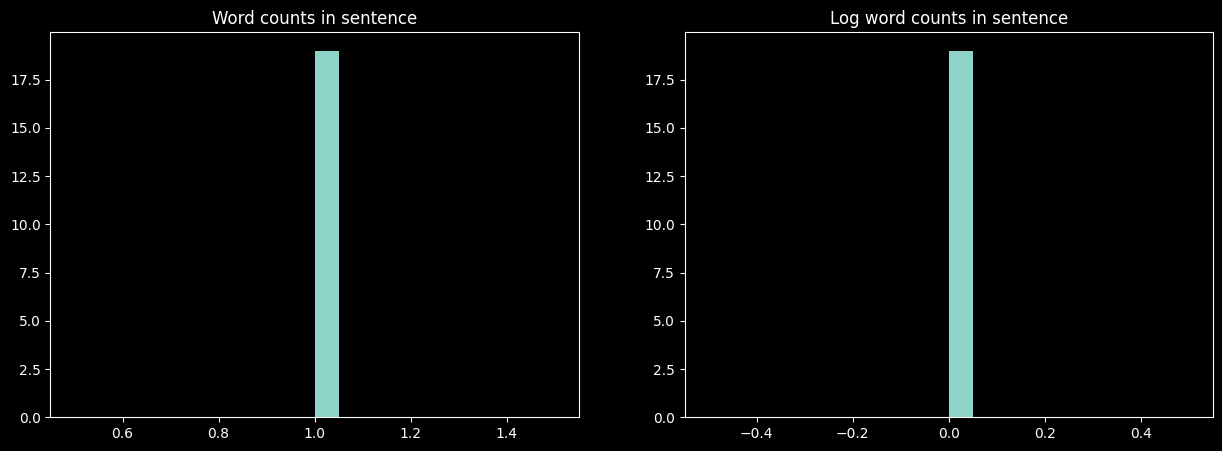

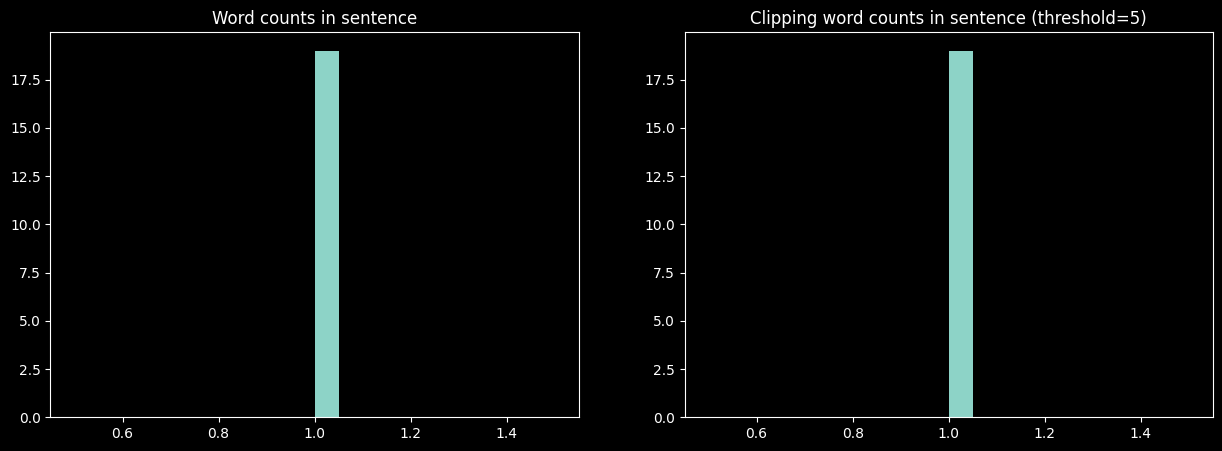

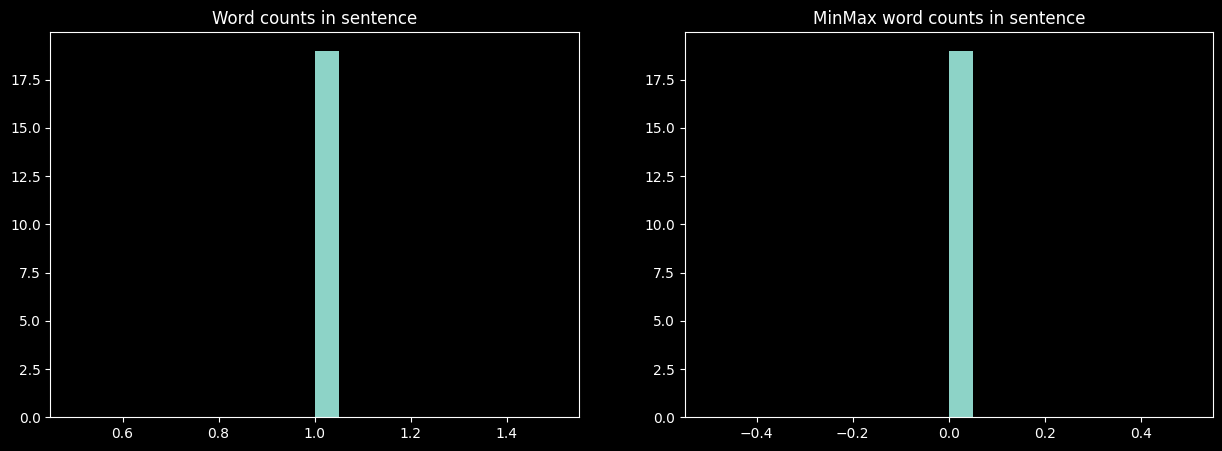

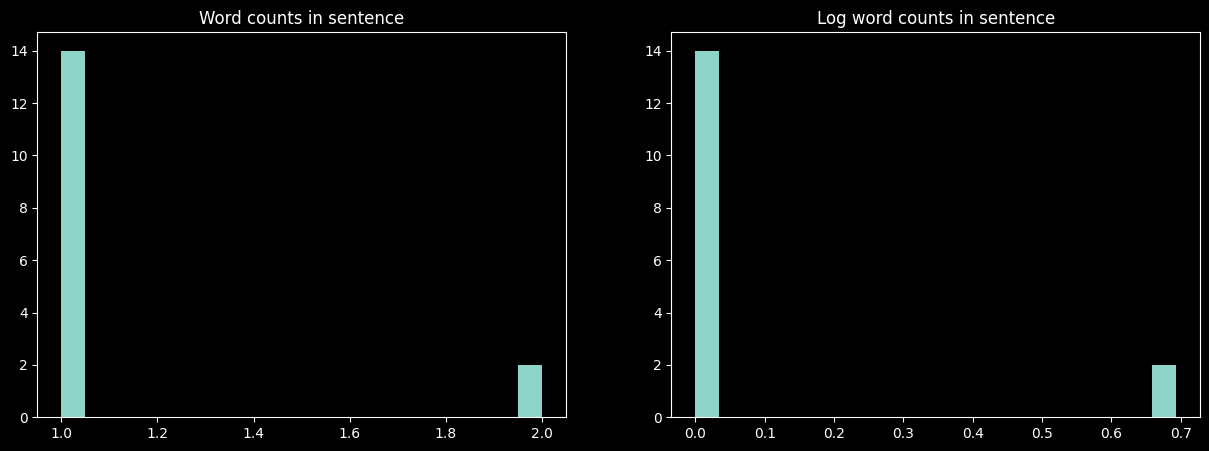

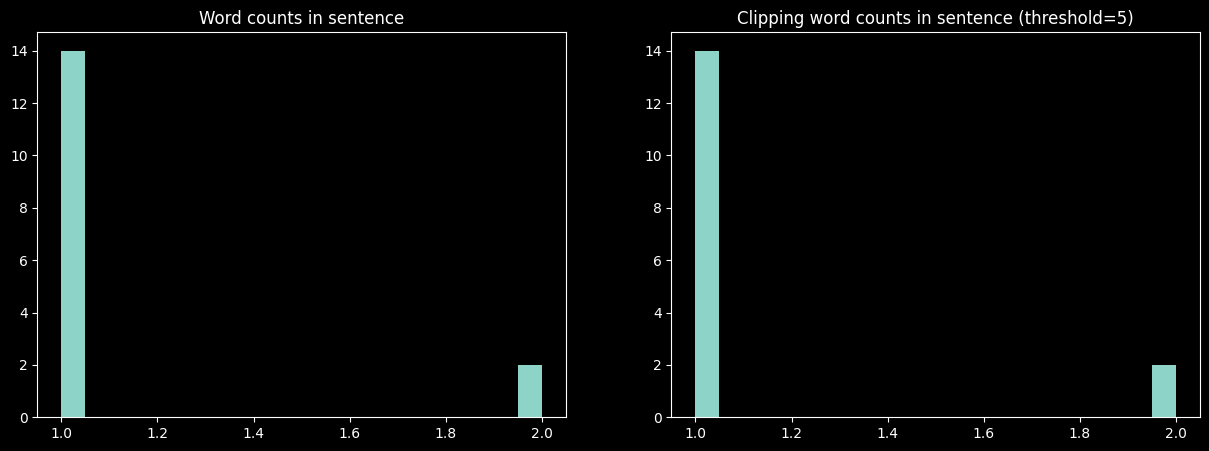

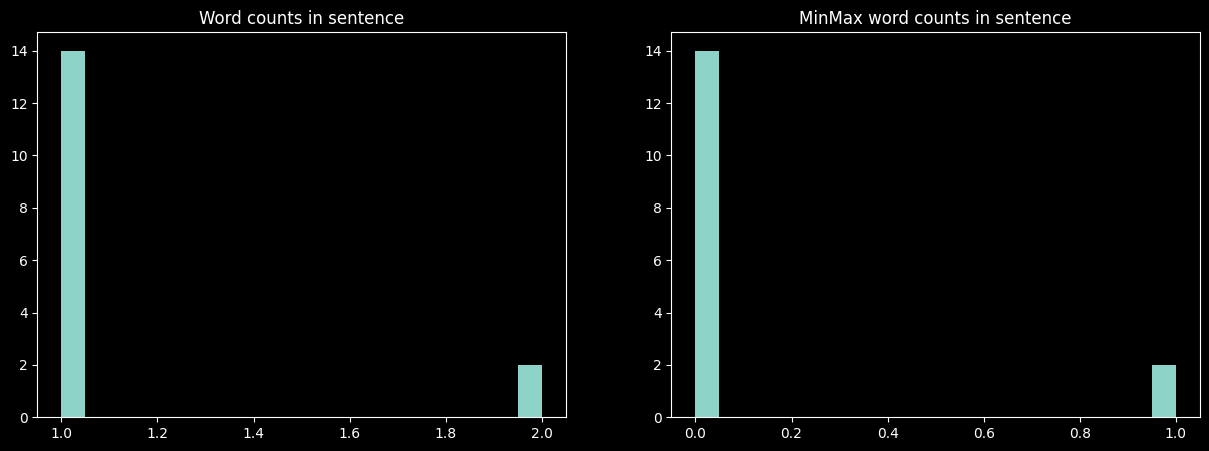

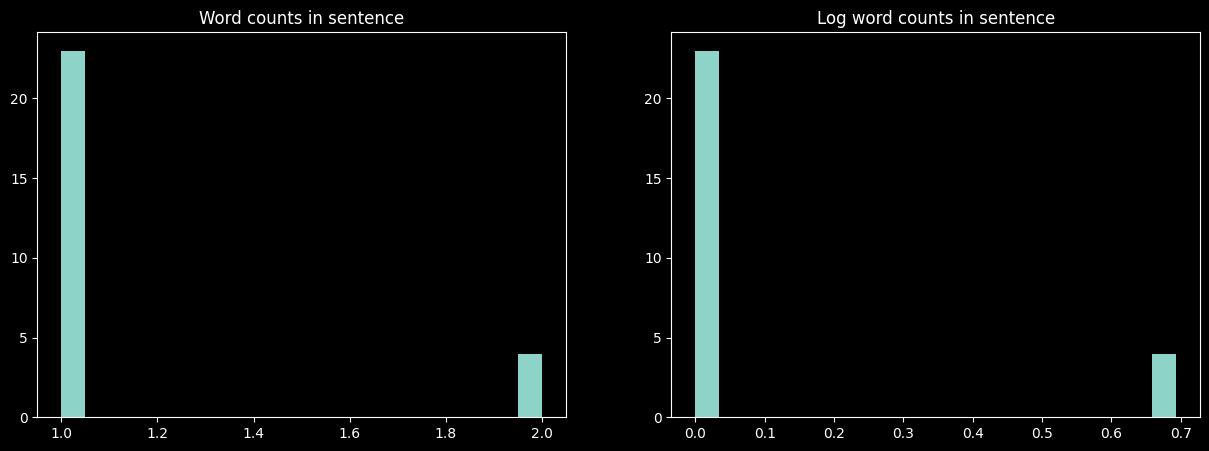

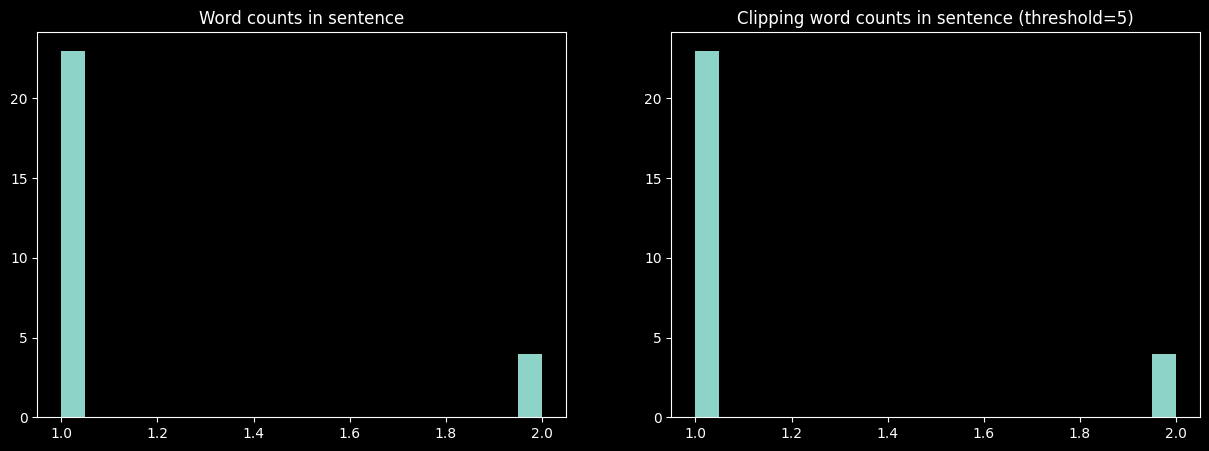

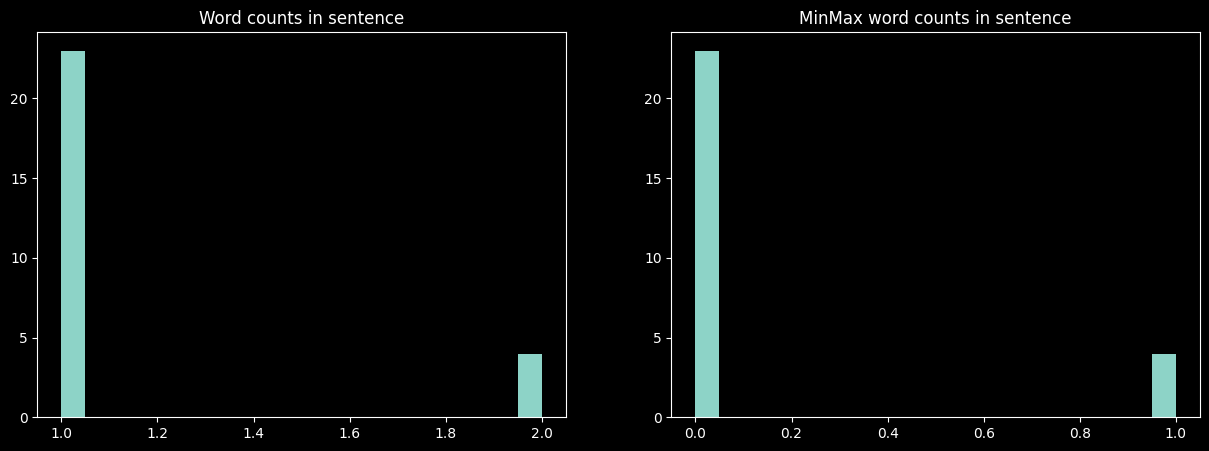

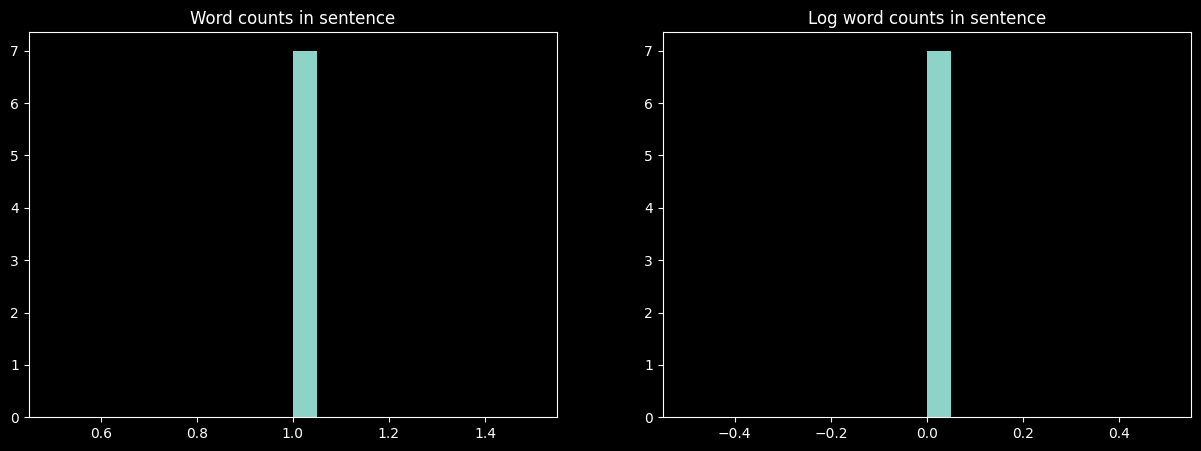

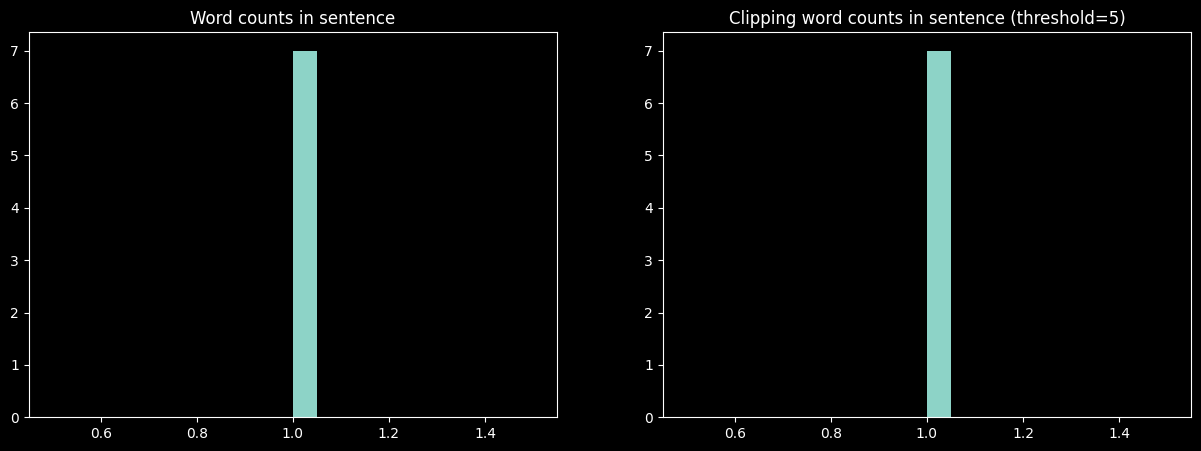

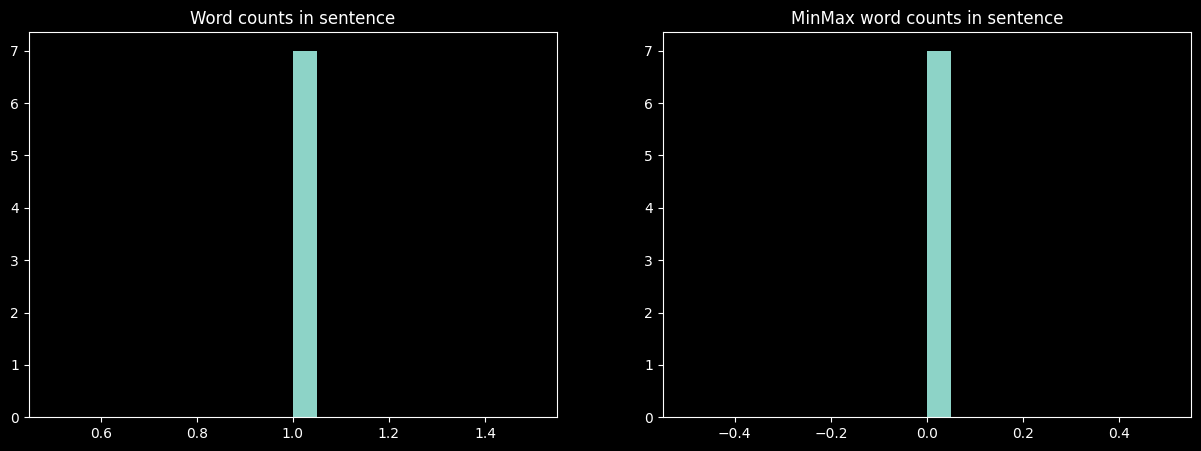

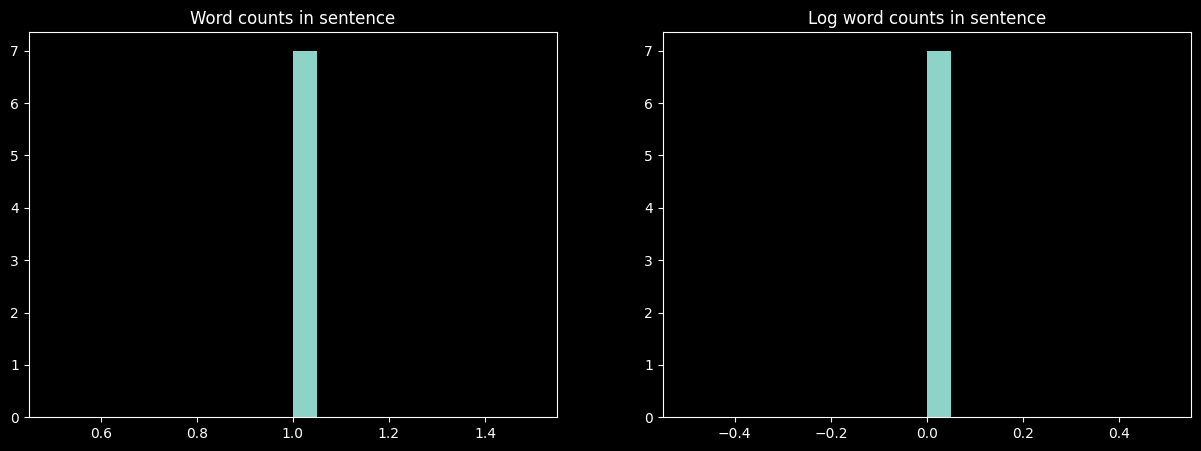

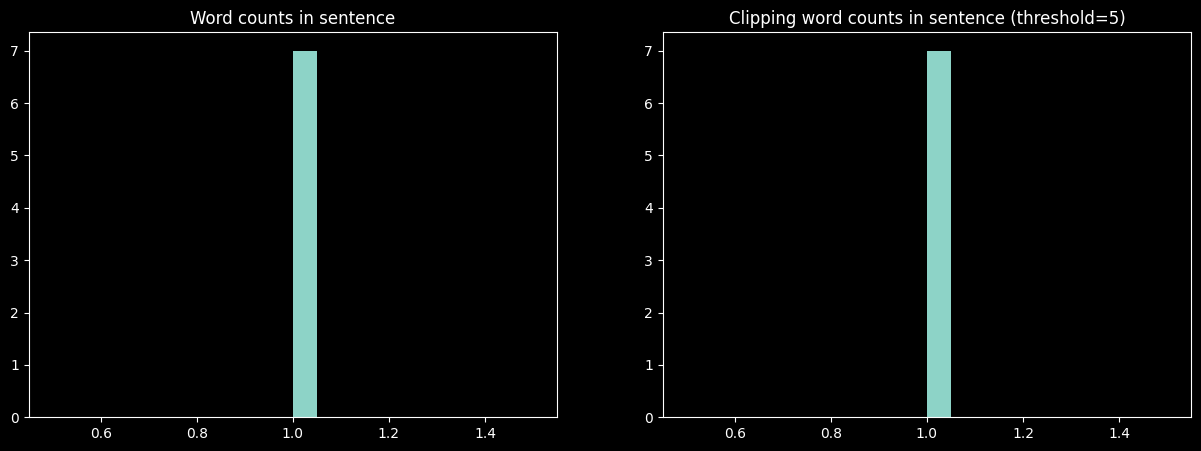

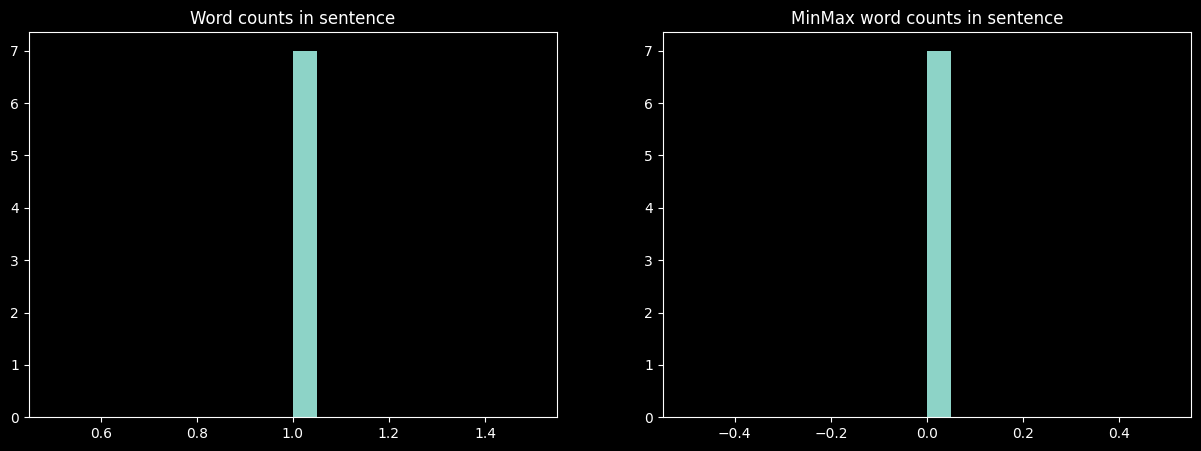

In [11]:
from nltk import sent_tokenize, word_tokenize

sentences = sent_tokenize(text)
print(sentences)
word_counts_per_sentence = []

for sentence in sentences:
    words = word_tokenize(sentence)
    counts = [words.count(word) for word in words]

    plotData(counts, logNormalize(counts), "Word counts in sentence", "Log word counts in sentence")
    plotData(counts, clippingNormalize(counts, thresholdMax=5), "Word counts in sentence", "Clipping word counts in sentence (threshold=5)")
    plotData(counts, minMaxNormalize(counts), "Word counts in sentence", "MinMax word counts in sentence")